# Week 2–3: Exploratory Data Analysis

EDA for Dataset: `sold_residential_combined.csv`.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined sold residential dataset
sold = pd.read_csv("sold_residential_combined.csv", low_memory=False)

print(sold.shape)
sold.head()

(414054, 85)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,SourceMonth,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,6472.0,NaN,NaN,True,True,202401,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,NaN,NaN,NaN,True,True,202401,NaN,NaN,NaN,NaN
2,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,NaN,NaN,NaN,True,True,202401,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,0.0,11219.0,NaN,False,False,202401,NaN,NaN,NaN,NaN
4,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,NaN,74487.6,NaN,False,False,202401,NaN,NaN,NaN,NaN


In [154]:
# Load the combined sold residential dataset
listings = pd.read_csv("listings_residential_combined.csv", low_memory=False)

print(listings.shape)
listings.head()

(547162, 85)


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,SourceMonth
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704,202401
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades,202401
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road,202401
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road,202401
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront,202401


#### Dataset Understanding

In [107]:
#identify number of rows and columns
sold.shape

(414054, 85)

In [108]:
#review column data types
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 414054 entries, 0 to 414053
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      265465 non-null  str    
 1   ViewYN                        378790 non-null  object 
 2   WaterfrontYN                  259 non-null     object 
 3   BasementYN                    8102 non-null    object 
 4   PoolPrivateYN                 378388 non-null  object 
 5   OriginalListPrice             413298 non-null  float64
 6   ListingKey                    414054 non-null  int64  
 7   ListAgentEmail                412989 non-null  str    
 8   CloseDate                     414054 non-null  str    
 9   ClosePrice                    414052 non-null  float64
 10  ListAgentFirstName            410945 non-null  str    
 11  ListAgentLastName             414012 non-null  str    
 12  Latitude                      409950 non-null  float64


In [109]:
#High missing columns
threshold = 0.5  # counts as "high" if more than 50% of the column is null

for col in sold.columns:
    null_pct = sold[col].isnull().mean()
    if null_pct > threshold:
        print(col, f"{null_pct:.1%} missing")


WaterfrontYN 99.9% missing
BasementYN 98.0% missing
CoListOfficeName 76.3% missing
CoListAgentFirstName 77.1% missing
CoListAgentLastName 77.0% missing
FireplacesTotal 100.0% missing
AssociationFeeFrequency 58.3% missing
AboveGradeFinishedArea 100.0% missing
TaxAnnualAmount 100.0% missing
ElementarySchool 86.7% missing
BuilderName 95.1% missing
SubdivisionName 62.8% missing
BuyerAgencyCompensationType 86.2% missing
BuyerAgencyCompensation 86.2% missing
TaxYear 100.0% missing
BuildingAreaTotal 93.0% missing
ElementarySchoolDistrict 100.0% missing
CoBuyerAgentFirstName 90.9% missing
BelowGradeFinishedArea 99.4% missing
BusinessType 100.0% missing
CoveredSpaces 100.0% missing
MiddleOrJuniorSchool 86.6% missing
HighSchool 82.6% missing
LotSizeDimensions 95.1% missing
MiddleOrJuniorSchoolDistrict 100.0% missing
latfilled 73.9% missing
lonfilled 73.9% missing
OriginatingSystemName 89.3% missing
OriginatingSystemSubName 89.3% missing


In [110]:
#separating market analysis fields and metadata fields

# Market analysis fields (Real Estate Data Analyst Primer, pp. 1–2)
market_cols = [
    "ListingKey",
    "ListingContractDate",
    "ListPrice",
    "ClosePrice",
    "PurchaseContractDate",
    "CloseDate",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "Latitude",
    "Longitude",
    "UnparsedAddress",
]

# Metadata = every other column, plus ListingKey so the two can be joined back
meta_cols = ["ListingKey"] + [c for c in sold.columns if c not in market_cols]

sold_market_analysis = sold[market_cols].copy()
sold_meta_data = sold[meta_cols].copy()

print("Market analysis:", sold_market_analysis.shape)
print("Metadata:", sold_meta_data.shape)

Market analysis: (414054, 12)
Metadata: (414054, 74)


#### Missing Value Analysis

In [111]:
# more than 90% missing

threshold_90 = 0.9  

high_missing_cols = []
for col in sold.columns:
    null_pct = sold[col].isnull().mean()
    if null_pct > threshold_90:
        high_missing_cols.append(col)
        print(col, f"{null_pct:.1%} missing")

print(f"\n{len(high_missing_cols)} columns are more than 90% missing")

WaterfrontYN 99.9% missing
BasementYN 98.0% missing
FireplacesTotal 100.0% missing
AboveGradeFinishedArea 100.0% missing
TaxAnnualAmount 100.0% missing
BuilderName 95.1% missing
TaxYear 100.0% missing
BuildingAreaTotal 93.0% missing
ElementarySchoolDistrict 100.0% missing
CoBuyerAgentFirstName 90.9% missing
BelowGradeFinishedArea 99.4% missing
BusinessType 100.0% missing
CoveredSpaces 100.0% missing
LotSizeDimensions 95.1% missing
MiddleOrJuniorSchoolDistrict 100.0% missing

15 columns are more than 90% missing


In [112]:
#drop all columns that are above 90% missing
sold = sold.drop(columns=high_missing_cols)

# Remove them from the split DataFrames too, since those were built before this step
sold_market_analysis = sold_market_analysis.drop(columns=high_missing_cols, errors="ignore")
sold_meta_data = sold_meta_data.drop(columns=high_missing_cols, errors="ignore")

print("sold:", sold.shape)
print("sold_market_analysis:", sold_market_analysis.shape)
print("sold_meta_data:", sold_meta_data.shape)

sold: (414054, 70)
sold_market_analysis: (414054, 12)
sold_meta_data: (414054, 59)


#### Numeric Distribution Review

Close Price

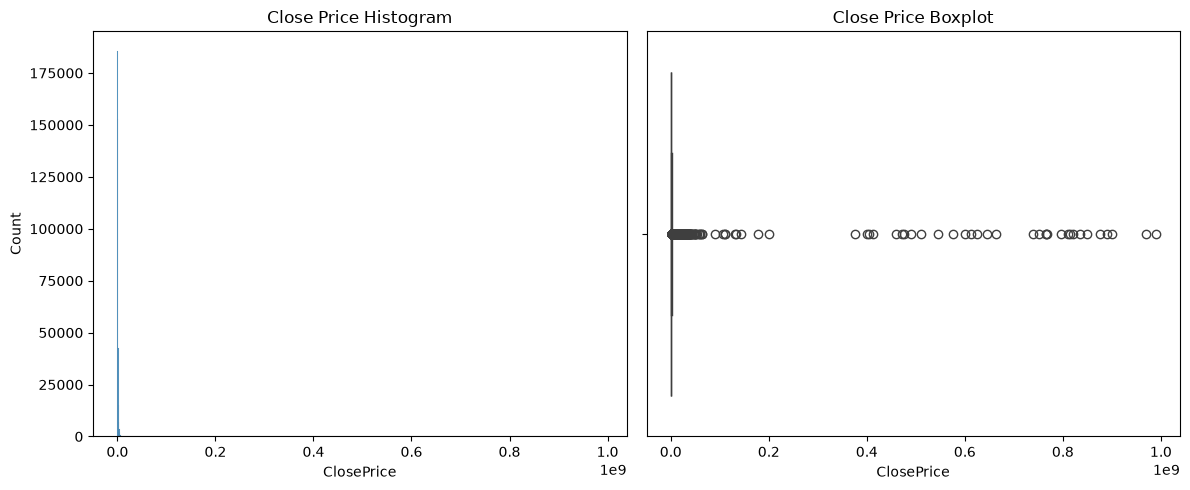

count    4.140520e+05
mean     1.193864e+06
std      6.290122e+06
min      0.000000e+00
25%      5.750000e+05
50%      8.230000e+05
75%      1.300000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

In [113]:
#Histogram and boxplot of close price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="ClosePrice", ax=axes[0])
axes[0].set_title("Close Price Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="ClosePrice", ax=axes[1])
axes[1].set_title("Close Price Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['ClosePrice'].describe()

In [114]:
#Identifying outliers using IQR, IQR = Q3-Q1

Q1 = sold['ClosePrice'].quantile(0.25)
Q3 = sold['ClosePrice'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
close_lower = Q1 - (1.5 * IQR)
close_upper = Q3 + (1.5 * IQR)

print('Any datapoint less than: ', close_lower, 'is an outlier')
print('Any datapoint greater than: ', close_upper, 'is an outlier')

Any datapoint less than:  -512500.0 is an outlier
Any datapoint greater than:  2387500.0 is an outlier


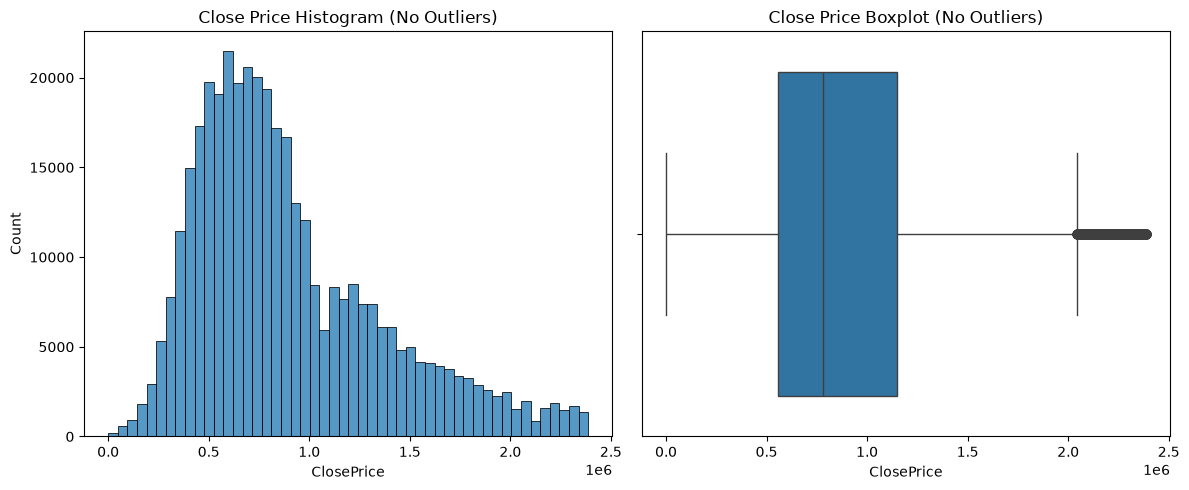

In [115]:
#New histogram and boxplots without outliers to see true distribution
#Histogram and boxplot of close price
close_no_outliers = sold[(sold['ClosePrice'] >= close_lower) & (sold['ClosePrice'] <= close_upper)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(close_no_outliers, x="ClosePrice", bins=50, ax=axes[0])
axes[0].set_title("Close Price Histogram (No Outliers)")

sns.boxplot(close_no_outliers, x="ClosePrice", ax=axes[1])
axes[1].set_title("Close Price Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

List Price

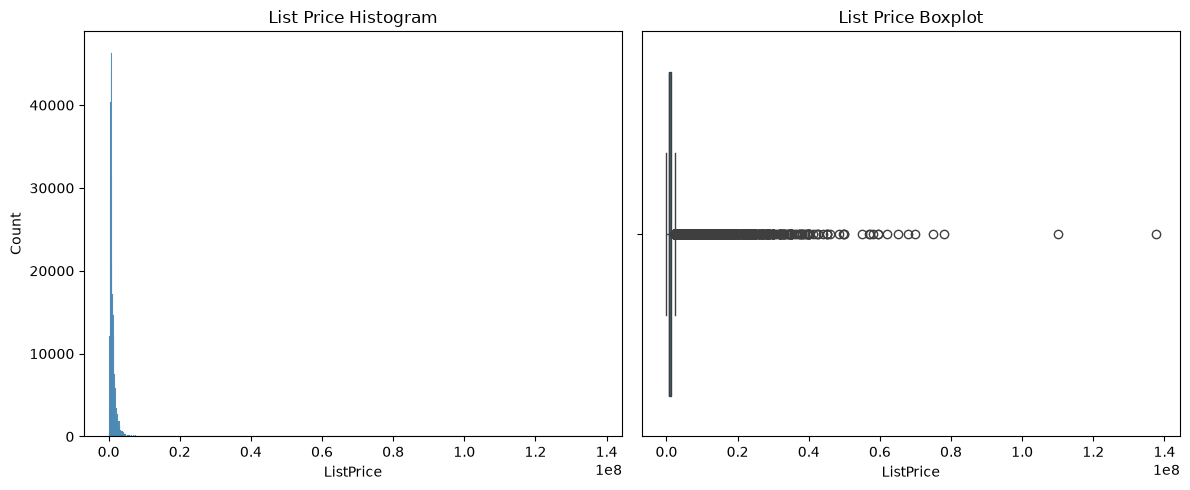

count    4.140540e+05
mean     1.140462e+06
std      1.359497e+06
min      5.250000e+02
25%      5.761670e+05
50%      8.150000e+05
75%      1.295000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

In [116]:
#Histogram and boxplot of list price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="ListPrice", ax=axes[0])
axes[0].set_title("List Price Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="ListPrice", ax=axes[1])
axes[1].set_title("List Price Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['ListPrice'].describe()

In [117]:
#Identifying outliers in ListPrice using IQR, IQR = Q3-Q1

Q1 = sold['ListPrice'].quantile(0.25)
Q3 = sold['ListPrice'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('ListPrice')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

ListPrice
Any datapoint less than:  -502082.5 is an outlier
Any datapoint greater than:  2373249.5 is an outlier


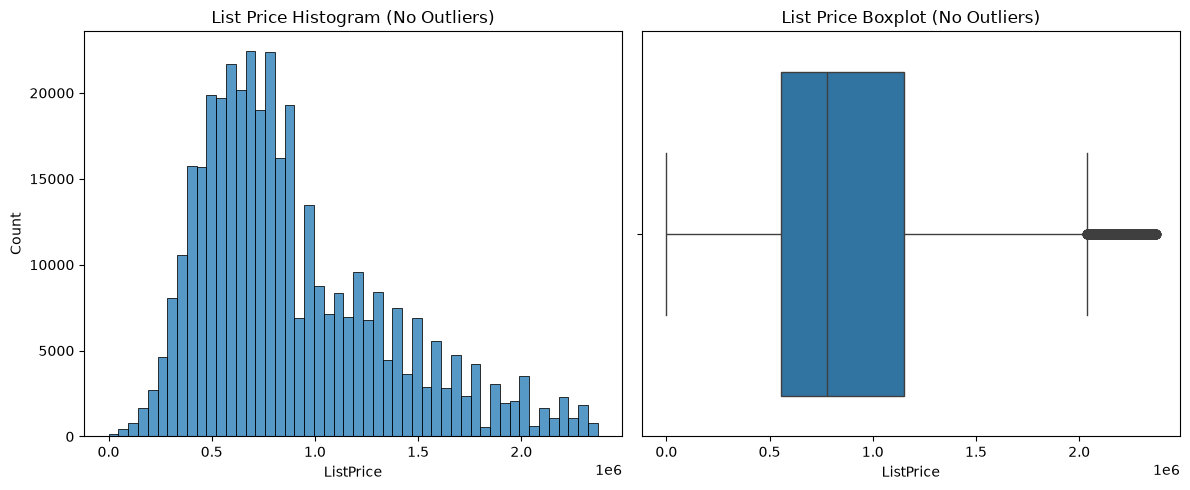

In [118]:
#New histogram and boxplot of list price without outliers
Q1 = sold['ListPrice'].quantile(0.25)
Q3 = sold['ListPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_lp = Q1 - (1.5 * IQR)
upper_lim_lp = Q3 + (1.5 * IQR)

lp_no_outliers = sold[(sold['ListPrice'] >= lower_lim_lp) & (sold['ListPrice'] <= upper_lim_lp)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(lp_no_outliers, x="ListPrice", bins=50, ax=axes[0])
axes[0].set_title("List Price Histogram (No Outliers)")

sns.boxplot(lp_no_outliers, x="ListPrice", ax=axes[1])
axes[1].set_title("List Price Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Original List Price

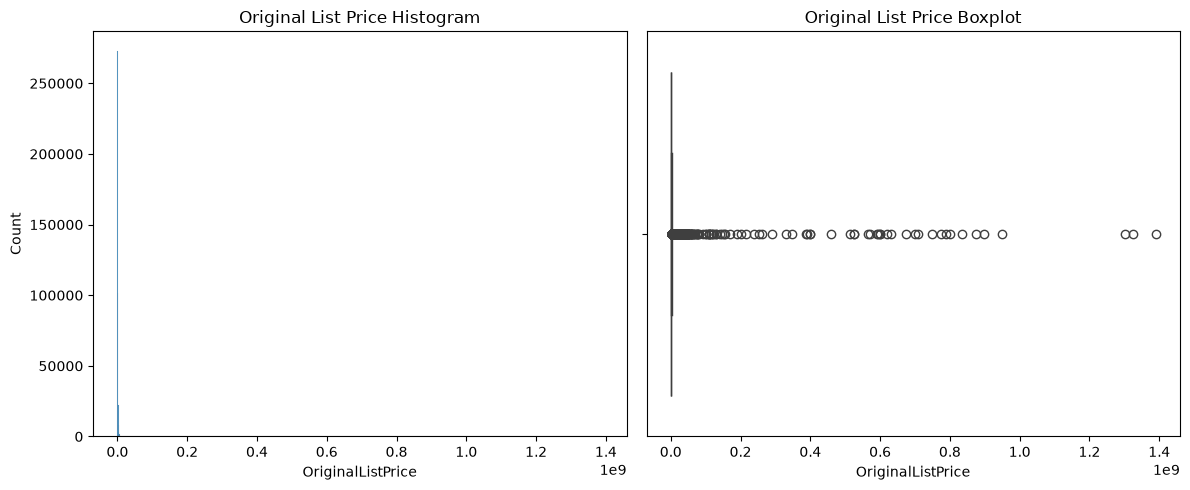

count    4.132980e+05
mean     1.225401e+06
std      6.709938e+06
min      0.000000e+00
25%      5.850000e+05
50%      8.250000e+05
75%      1.299000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64

In [119]:
#Histogram and boxplot of original list price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="OriginalListPrice", ax=axes[0])
axes[0].set_title("Original List Price Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="OriginalListPrice", ax=axes[1])
axes[1].set_title("Original List Price Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['OriginalListPrice'].describe()

In [120]:
#Identifying outliers in OriginalListPrice using IQR, IQR = Q3-Q1

Q1 = sold['OriginalListPrice'].quantile(0.25)
Q3 = sold['OriginalListPrice'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('OriginalListPrice')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

OriginalListPrice
Any datapoint less than:  -486000.0 is an outlier
Any datapoint greater than:  2370000.0 is an outlier


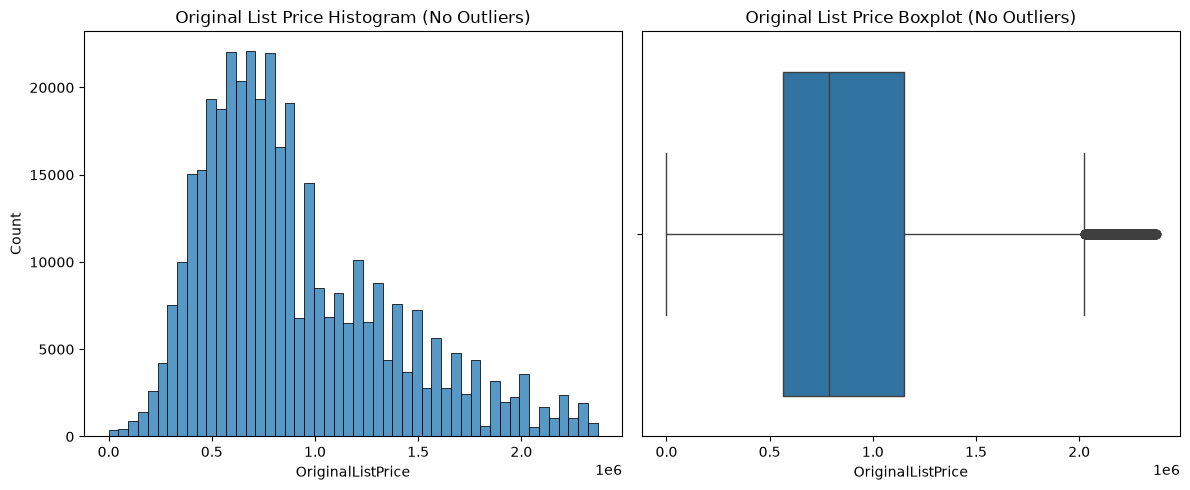

In [121]:
#New histogram and boxplot of original list price without outliers
Q1 = sold['OriginalListPrice'].quantile(0.25)
Q3 = sold['OriginalListPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_olp = Q1 - (1.5 * IQR)
upper_lim_olp = Q3 + (1.5 * IQR)

olp_no_outliers = sold[(sold['OriginalListPrice'] >= lower_lim_olp) & (sold['OriginalListPrice'] <= upper_lim_olp)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(olp_no_outliers, x="OriginalListPrice", bins=50, ax=axes[0])
axes[0].set_title("Original List Price Histogram (No Outliers)")

sns.boxplot(olp_no_outliers, x="OriginalListPrice", ax=axes[1])
axes[1].set_title("Original List Price Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Living Area

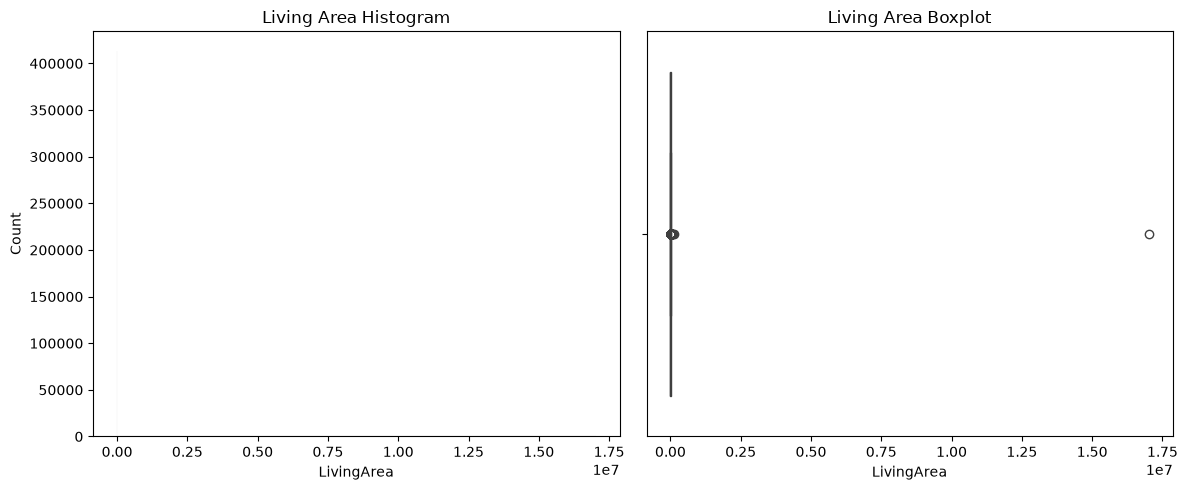

count    4.138200e+05
mean     1.903791e+03
std      2.647620e+04
min      0.000000e+00
25%      1.248000e+03
50%      1.642000e+03
75%      2.219000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

In [122]:
#Histogram and boxplot of living area
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="LivingArea", ax=axes[0])
axes[0].set_title("Living Area Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="LivingArea", ax=axes[1])
axes[1].set_title("Living Area Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['LivingArea'].describe()

In [123]:
#Identifying outliers in LivingArea using IQR, IQR = Q3-Q1

Q1 = sold['LivingArea'].quantile(0.25)
Q3 = sold['LivingArea'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('LivingArea')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

LivingArea
Any datapoint less than:  -208.5 is an outlier
Any datapoint greater than:  3675.5 is an outlier


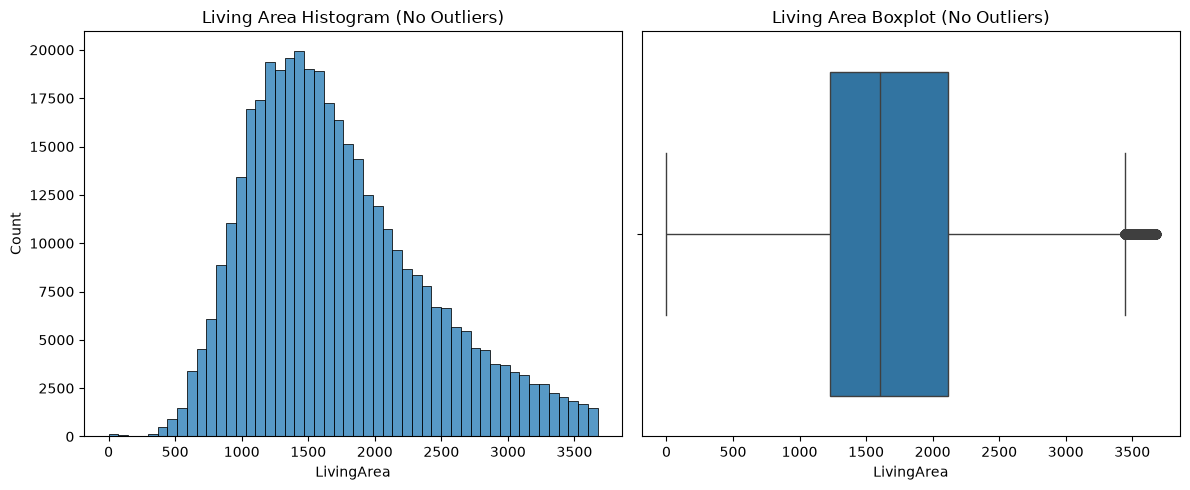

In [124]:
#New histogram and boxplot of living area without outliers
Q1 = sold['LivingArea'].quantile(0.25)
Q3 = sold['LivingArea'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_la = Q1 - (1.5 * IQR)
upper_lim_la = Q3 + (1.5 * IQR)

la_no_outliers = sold[(sold['LivingArea'] >= lower_lim_la) & (sold['LivingArea'] <= upper_lim_la)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(la_no_outliers, x="LivingArea", bins=50, ax=axes[0])
axes[0].set_title("Living Area Histogram (No Outliers)")

sns.boxplot(la_no_outliers, x="LivingArea", ax=axes[1])
axes[1].set_title("Living Area Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Lot Size Acres

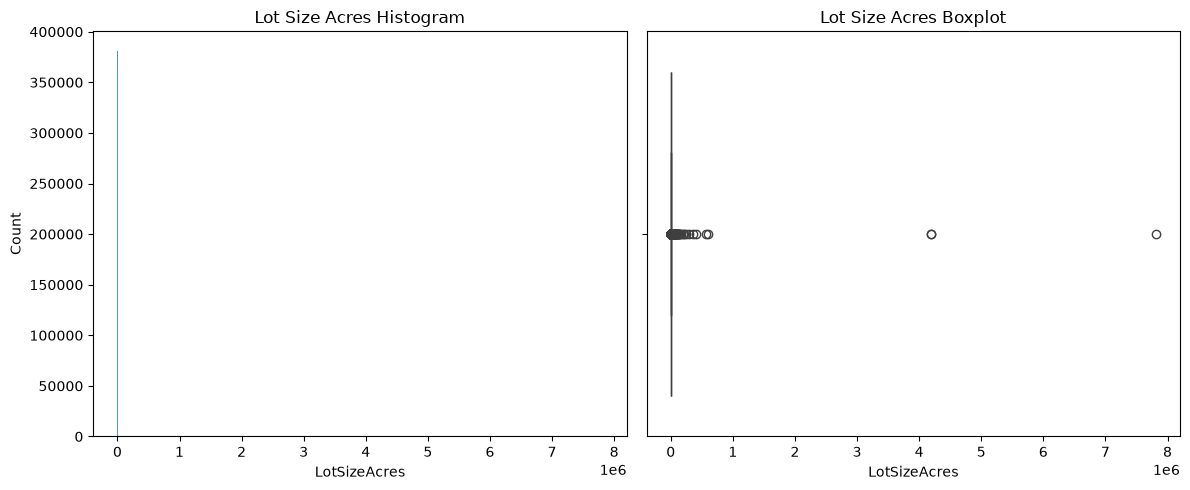

count    3.815190e+05
mean     6.630318e+01
std      1.599818e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.664000e-01
75%      2.730000e-01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64

In [125]:
#Histogram and boxplot of lot size acres
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="LotSizeAcres", ax=axes[0])
axes[0].set_title("Lot Size Acres Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="LotSizeAcres", ax=axes[1])
axes[1].set_title("Lot Size Acres Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['LotSizeAcres'].describe()

In [126]:
#Identifying outliers in LotSizeAcres using IQR, IQR = Q3-Q1

Q1 = sold['LotSizeAcres'].quantile(0.25)
Q3 = sold['LotSizeAcres'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('LotSizeAcres')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

LotSizeAcres
Any datapoint less than:  -0.10950000000000004 is an outlier
Any datapoint greater than:  0.5025000000000001 is an outlier


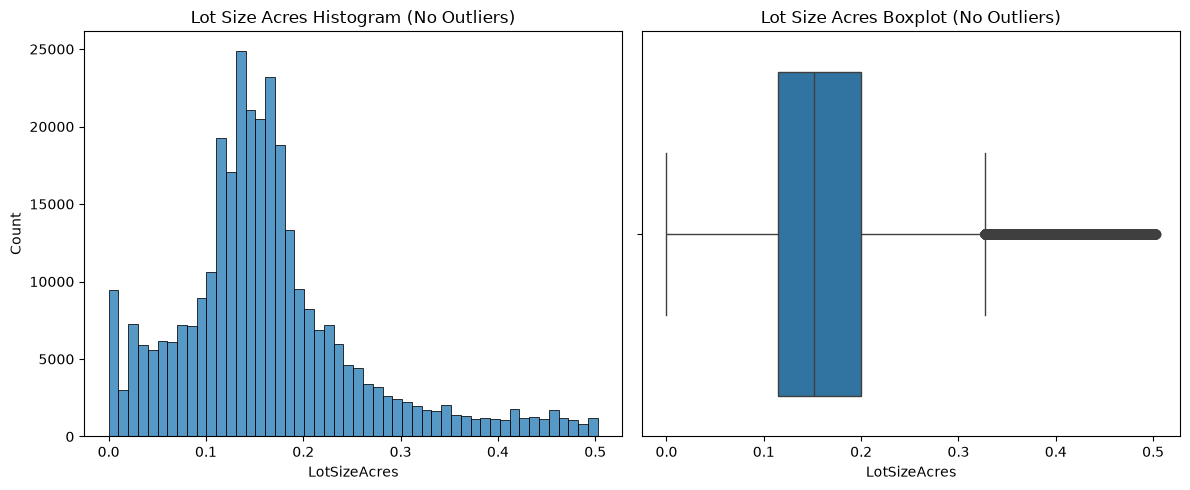

In [127]:
#New histogram and boxplot of lot size acres without outliers
Q1 = sold['LotSizeAcres'].quantile(0.25)
Q3 = sold['LotSizeAcres'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_lsa = Q1 - (1.5 * IQR)
upper_lim_lsa = Q3 + (1.5 * IQR)

lsa_no_outliers = sold[(sold['LotSizeAcres'] >= lower_lim_lsa) & (sold['LotSizeAcres'] <= upper_lim_lsa)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(lsa_no_outliers, x="LotSizeAcres", bins=50, ax=axes[0])
axes[0].set_title("Lot Size Acres Histogram (No Outliers)")

sns.boxplot(lsa_no_outliers, x="LotSizeAcres", ax=axes[1])
axes[1].set_title("Lot Size Acres Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Bedrooms Total

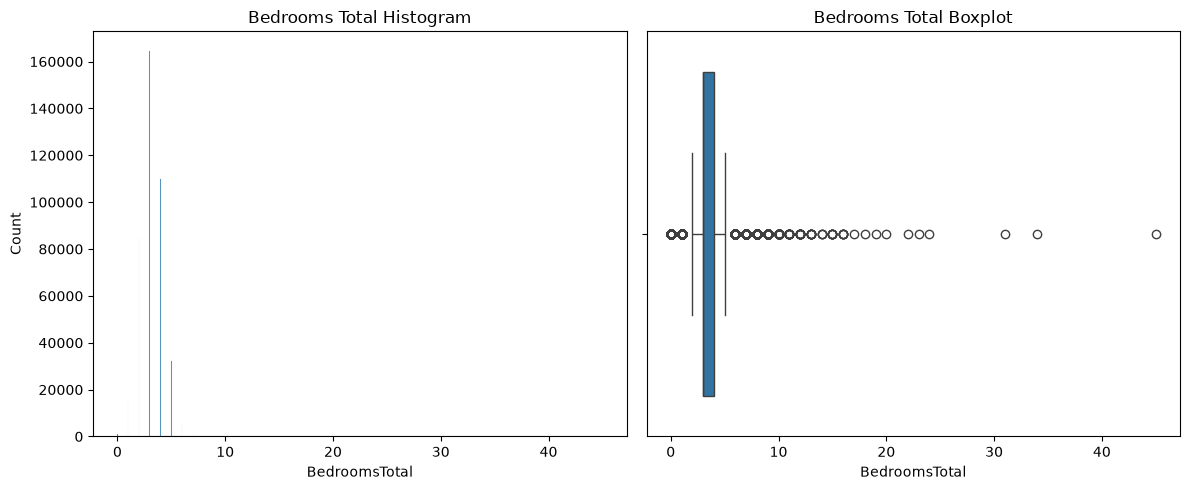

count    414043.000000
mean          3.201056
std           1.067103
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

In [128]:
#Histogram and boxplot of bedrooms total
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="BedroomsTotal", ax=axes[0])
axes[0].set_title("Bedrooms Total Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="BedroomsTotal", ax=axes[1])
axes[1].set_title("Bedrooms Total Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['BedroomsTotal'].describe()

In [129]:
#Identifying outliers in BedroomsTotal using IQR, IQR = Q3-Q1

Q1 = sold['BedroomsTotal'].quantile(0.25)
Q3 = sold['BedroomsTotal'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('BedroomsTotal')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

BedroomsTotal
Any datapoint less than:  1.5 is an outlier
Any datapoint greater than:  5.5 is an outlier


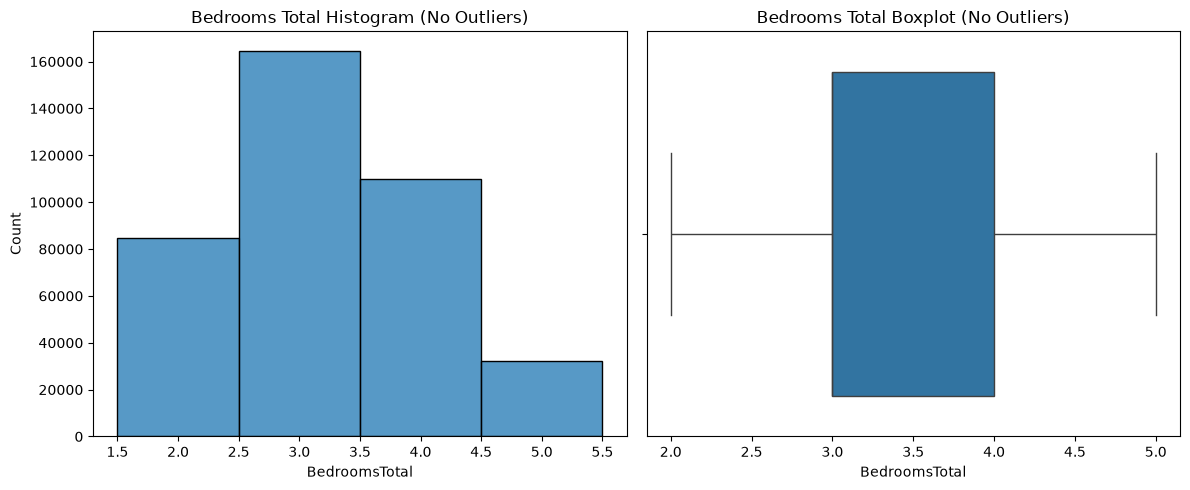

In [141]:
#New histogram and boxplot of bedrooms total without outliers
Q1 = sold['BedroomsTotal'].quantile(0.25)
Q3 = sold['BedroomsTotal'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_bed = Q1 - (1.5 * IQR)
upper_lim_bed = Q3 + (1.5 * IQR)

bed_no_outliers = sold[(sold['BedroomsTotal'] >= lower_lim_bed) & (sold['BedroomsTotal'] <= upper_lim_bed)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(bed_no_outliers, x="BedroomsTotal", discrete=True, ax=axes[0])
axes[0].set_title("Bedrooms Total Histogram (No Outliers)")

sns.boxplot(bed_no_outliers, x="BedroomsTotal", ax=axes[1])
axes[1].set_title("Bedrooms Total Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Bathrooms Total

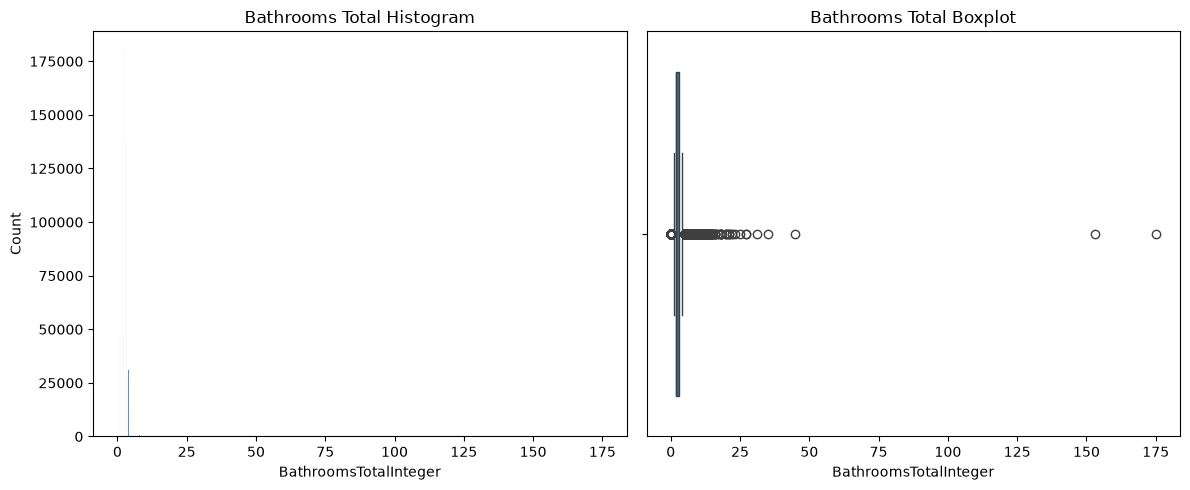

count    413985.000000
mean          2.534771
std           1.134152
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

In [131]:
#Histogram and boxplot of bathrooms total
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="BathroomsTotalInteger", ax=axes[0])
axes[0].set_title("Bathrooms Total Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="BathroomsTotalInteger", ax=axes[1])
axes[1].set_title("Bathrooms Total Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['BathroomsTotalInteger'].describe()

In [132]:
#Identifying outliers in BathroomsTotalInteger using IQR, IQR = Q3-Q1

Q1 = sold['BathroomsTotalInteger'].quantile(0.25)
Q3 = sold['BathroomsTotalInteger'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('BathroomsTotalInteger')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

BathroomsTotalInteger
Any datapoint less than:  0.5 is an outlier
Any datapoint greater than:  4.5 is an outlier


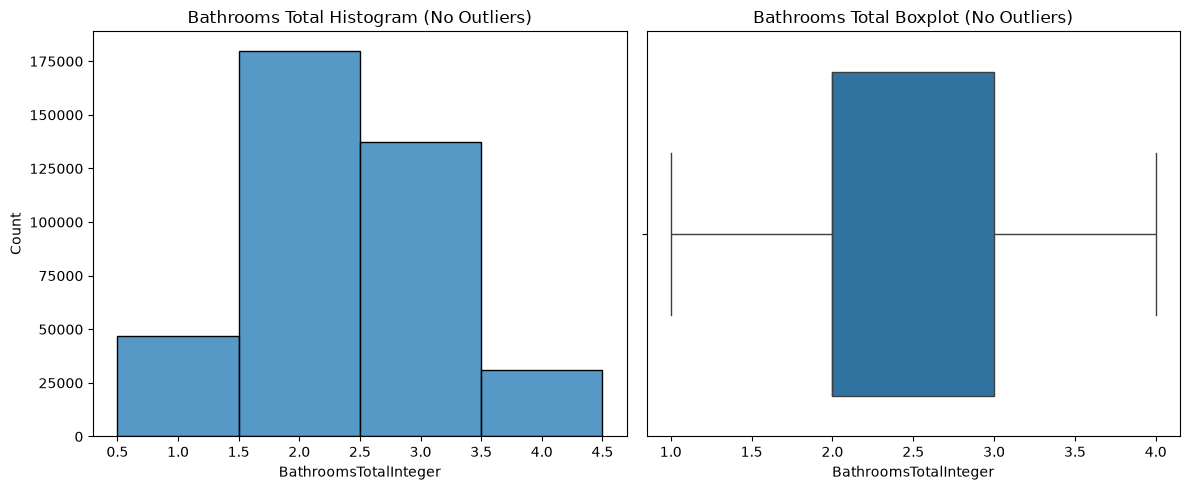

In [133]:
#New histogram and boxplot of bathrooms total without outliers
Q1 = sold['BathroomsTotalInteger'].quantile(0.25)
Q3 = sold['BathroomsTotalInteger'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_bath = Q1 - (1.5 * IQR)
upper_lim_bath = Q3 + (1.5 * IQR)

bath_no_outliers = sold[(sold['BathroomsTotalInteger'] >= lower_lim_bath) & (sold['BathroomsTotalInteger'] <= upper_lim_bath)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(bath_no_outliers, x="BathroomsTotalInteger", discrete=True, ax=axes[0])
axes[0].set_title("Bathrooms Total Histogram (No Outliers)")

sns.boxplot(bath_no_outliers, x="BathroomsTotalInteger", ax=axes[1])
axes[1].set_title("Bathrooms Total Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Days On Market

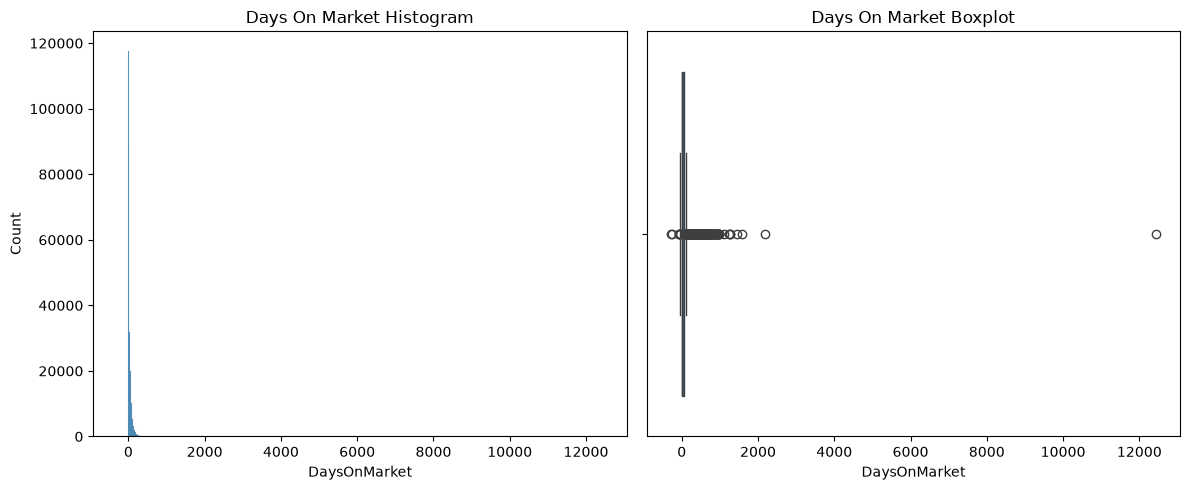

count    414054.000000
mean         37.355123
std          53.592461
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

In [134]:
#Histogram and boxplot of days on market
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="DaysOnMarket", ax=axes[0])
axes[0].set_title("Days On Market Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="DaysOnMarket", ax=axes[1])
axes[1].set_title("Days On Market Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['DaysOnMarket'].describe()

In [142]:
#Identifying outliers in DaysOnMarket using IQR, IQR = Q3-Q1

Q1 = sold['DaysOnMarket'].quantile(0.25)
Q3 = sold['DaysOnMarket'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('DaysOnMarket')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')
print('Any datapoint less than: ', 0 , 'is not possible(manual fix)')


DaysOnMarket
Any datapoint less than:  -52.0 is an outlier
Any datapoint greater than:  108.0 is an outlier
Any datapoint less than:  0 is not possible(manual fix)


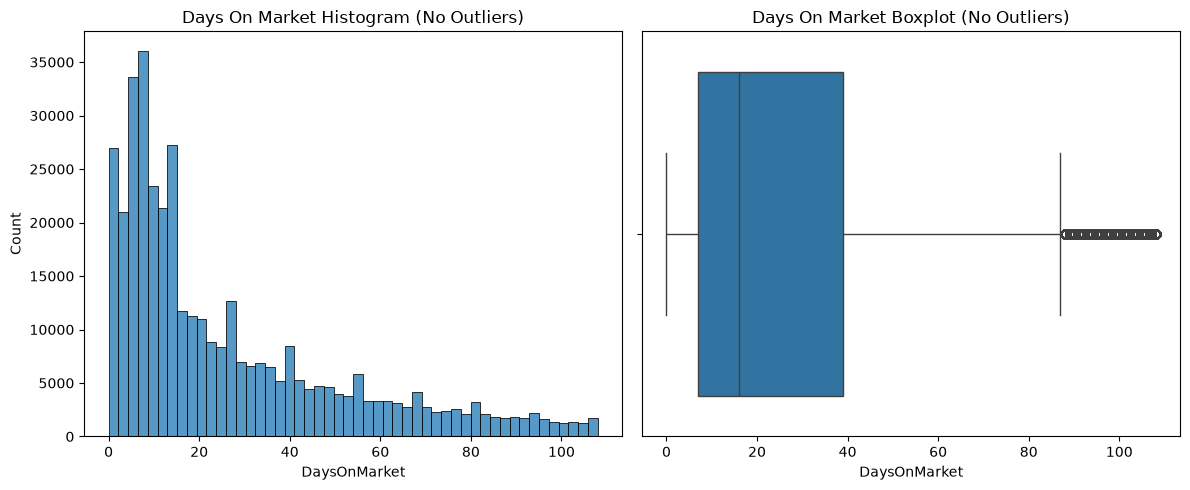

In [143]:
#New histogram and boxplot of days on market without outliers
Q1 = sold['DaysOnMarket'].quantile(0.25)
Q3 = sold['DaysOnMarket'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_dom = Q1 - (1.5 * IQR)
upper_lim_dom = Q3 + (1.5 * IQR)

dom_no_outliers = sold[(sold['DaysOnMarket'] >= 0) & (sold['DaysOnMarket'] <= upper_lim_dom)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(dom_no_outliers, x="DaysOnMarket", bins=50, ax=axes[0])
axes[0].set_title("Days On Market Histogram (No Outliers)")

sns.boxplot(dom_no_outliers, x="DaysOnMarket", ax=axes[1])
axes[1].set_title("Days On Market Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

Year Built

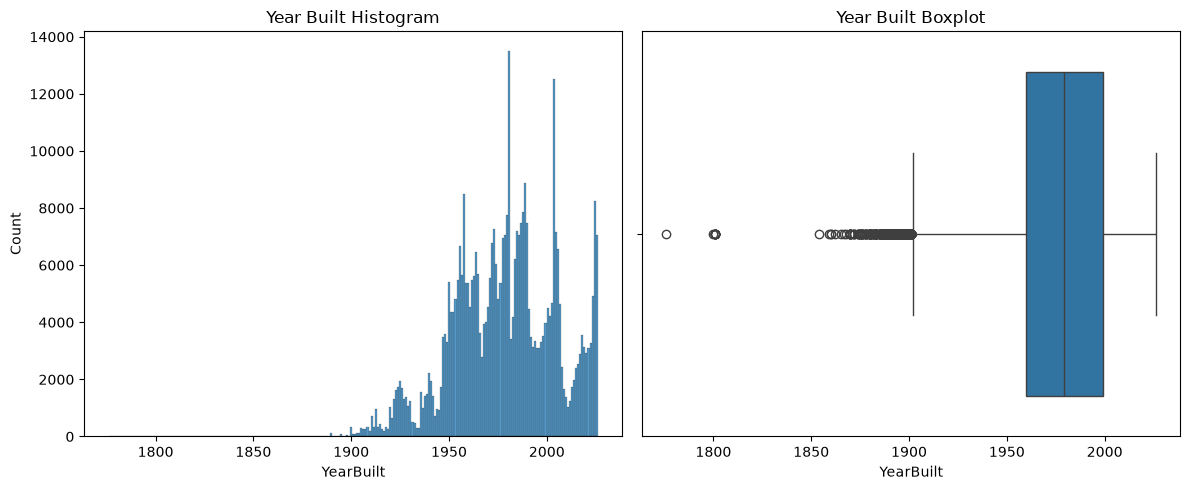

count    413682.000000
mean       1978.580477
std          26.278227
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

In [137]:
#Histogram and boxplot of year built
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the first graph on the first axis
sns.histplot(sold, x="YearBuilt", ax=axes[0])
axes[0].set_title("Year Built Histogram")

# Plot the second graph on the second axis
sns.boxplot(sold, x="YearBuilt", ax=axes[1])
axes[1].set_title("Year Built Boxplot")

# Display the side-by-side plots
plt.tight_layout()
plt.show()

# percentile summaries
sold['YearBuilt'].describe()

In [138]:
#Identifying outliers in YearBuilt using IQR, IQR = Q3-Q1

Q1 = sold['YearBuilt'].quantile(0.25)
Q3 = sold['YearBuilt'].quantile(0.75)

IQR = Q3 - Q1

#Any data point below the lower limit or above the upper limit is an outlier
lower_lim = Q1 - (1.5 * IQR)
upper_lim = Q3 + (1.5 * IQR)

print('YearBuilt')
print('Any datapoint less than: ', lower_lim, 'is an outlier')
print('Any datapoint greater than: ', upper_lim, 'is an outlier')

YearBuilt
Any datapoint less than:  1901.5 is an outlier
Any datapoint greater than:  2057.5 is an outlier


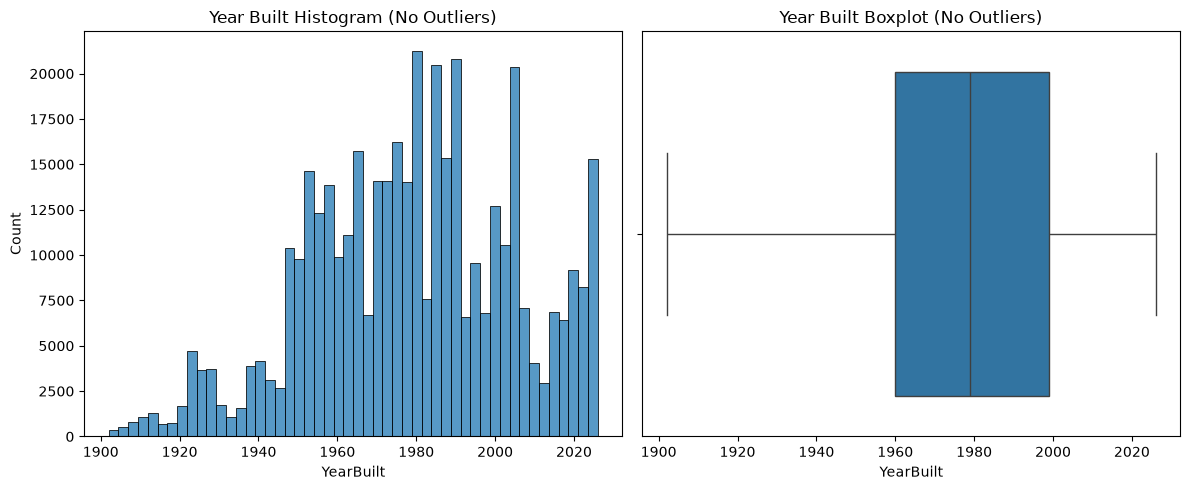

In [139]:
#New histogram and boxplot of year built without outliers
Q1 = sold['YearBuilt'].quantile(0.25)
Q3 = sold['YearBuilt'].quantile(0.75)
IQR = Q3 - Q1
lower_lim_yb = Q1 - (1.5 * IQR)
upper_lim_yb = Q3 + (1.5 * IQR)

yb_no_outliers = sold[(sold['YearBuilt'] >= lower_lim_yb) & (sold['YearBuilt'] <= upper_lim_yb)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(yb_no_outliers, x="YearBuilt", bins=50, ax=axes[0])
axes[0].set_title("Year Built Histogram (No Outliers)")

sns.boxplot(yb_no_outliers, x="YearBuilt", ax=axes[1])
axes[1].set_title("Year Built Boxplot (No Outliers)")

plt.tight_layout()
plt.show()

#### Suggested Intern Questions

- Which counties have the highest median prices?

- What is the Residential vs. other property type share?


- What are the median and average close prices?


In [150]:
print('median close price:' ,sold['ClosePrice'].median())
print('average close price:' ,sold['ClosePrice'].mean())


median close price: 823000.0
average close price: 1193864.0760070474


- What does the Days on Market distribution look like?

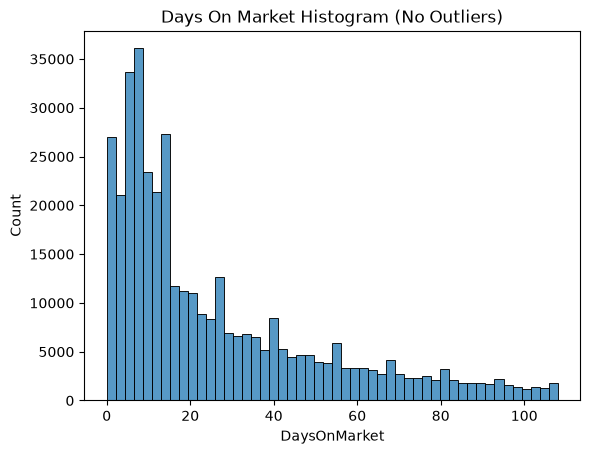

In [152]:
sns.histplot(dom_no_outliers, x="DaysOnMarket", bins=50)
plt.title("Days On Market Histogram (No Outliers)")
plt.tight_layout
plt.show()

- What percentage of homes sold above vs. below list price?


In [153]:
# Percentage of homes sold above, below, or at list price
valid = sold.dropna(subset=["ClosePrice", "ListPrice"])

above = (valid["ClosePrice"] > valid["ListPrice"]).mean()
below = (valid["ClosePrice"] < valid["ListPrice"]).mean()
at    = (valid["ClosePrice"] == valid["ListPrice"]).mean()

print(f"Sold above list price: {above:.1%}")
print(f"Sold below list price: {below:.1%}")
print(f"Sold at list price:    {at:.1%}")

Sold above list price: 40.1%
Sold below list price: 42.5%
Sold at list price:    17.4%


- Are there any apparent date consistency issues (e.g., close date before listing date)?
